# Session 20

#### Denoising - AutoEncoder (Encoder, Decoder,Bottleneck,DownScaling and Upscaling ) - Style Transformer - Transformers - Attention -  MediaPipe- pix2pix

What is a Transformer?

A Transformer is a deep learning architecture designed to process sequences (such as text, DNA, proteins, audio, or even images) by using attention instead of processing elements one by one.

Think of it as:

A Transformer is a neural network whose main job is to understand the relationships between all parts of an input sequence at the same time.

Notice I didn't mention Attention first.

Attention is how a Transformer works.

The Transformer is the entire architecture.

Just like:

A car = the whole machine

Engine = one important component

Similarly,

Transformer = whole architecture

Attention = its most important mechanism


---
A Transformer is a deep learning architecture for sequence modeling that processes all input tokens in parallel. It uses self-attention to model relationships between tokens, along with positional encoding, feed-forward networks, residual connections, and layer normalization to produce context-aware representations that can be used for tasks such as translation, text generation, question answering, and many others



--------

Transformer is a neural network architecture used for various machine learning tasks, especially in natural language processing and computer vision. It focuses on understanding relationships within data to process information more effectively.

Uses attention mechanisms to capture relationships between inputs

Processes entire sequences at once instead of step by step

Improves performance on tasks involving context and dependencies

Widely used across NLP, vision and other AI applications


## Class Material

Denoising MNIST Pictures

In [34]:
### Clip

In [36]:
from cProfile import label

import numpy as np
q = np.array([1,2,3,4,5,6,78,9])

In [37]:
np.clip(q,0,5,out=q)

array([1, 2, 3, 4, 5, 5, 5, 5])

In [1]:
### saved compressed

In [2]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

In [18]:
data = fetch_openml('mnist_784')

In [23]:
X_array = data.data.to_numpy()
y_array = data.target.to_numpy().astype(int)

In [27]:
np.savez_compressed('mnist_784.npz', data=X_array, target=y_array)

In [28]:
load_data = np.load("mnist_784.npz")

In [29]:
load_data

NpzFile 'mnist_784.npz' with keys: data, target

In [30]:
X = load_data["data"]

In [31]:
y = load_data["target"]

In [33]:
X = X[:20000]
y = y[:20000]

In [42]:
X = X.astype(np.float32) / 255.0

(array([1994., 2281., 1929., 2076., 1945., 1775., 1971., 2093., 1922.,
        2014.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

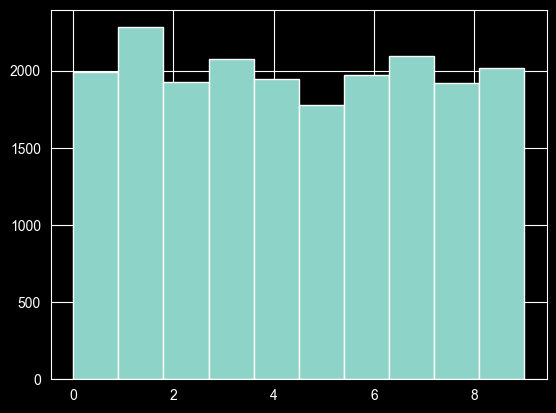

In [51]:
plt.hist(y, bins=10)

Text(0.5, 1.0, '2')

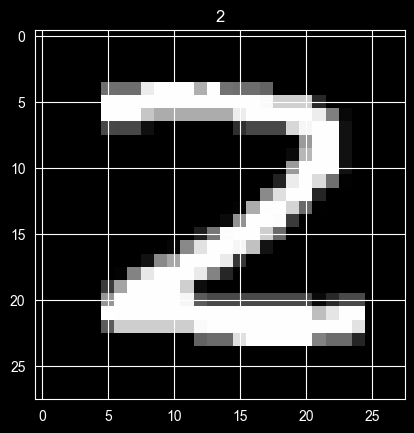

In [53]:
plt.imshow(X[220].reshape(28, 28), cmap='Greys_r')
plt.title(y[220])

In [65]:
## Noise making:
noise_factor = .6
noise = np.random.normal(loc=0,scale= 1,size=X.shape)

noisy_X = np.clip(X + noise_factor*noise,0,1)

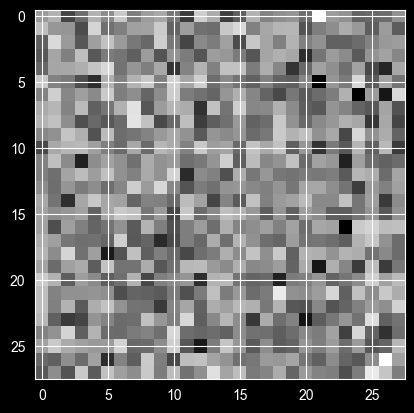

In [66]:
plt.imshow(noise[220].reshape(28,28), cmap='Greys_r')

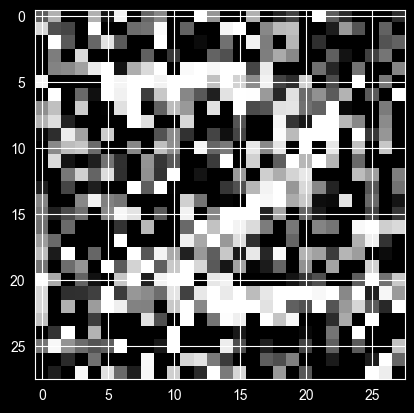

In [67]:
plt.imshow(noisy_X[220].reshape(28,28), cmap='Greys_r')

In [69]:
# Now AutoEncoder
autoencoder = MLPRegressor(hidden_layer_sizes=(512,256,128,64,128,256,512),verbose=True,max_iter=500)

autoencoder.fit(noisy_X, X)


Iteration 1, loss = 0.03371695
Iteration 2, loss = 0.02793006
Iteration 3, loss = 0.02405954
Iteration 4, loss = 0.02202322
Iteration 5, loss = 0.02087072
Iteration 6, loss = 0.02026560
Iteration 7, loss = 0.01986982
Iteration 8, loss = 0.01955968
Iteration 9, loss = 0.01930668
Iteration 10, loss = 0.01885419
Iteration 11, loss = 0.01828964
Iteration 12, loss = 0.01784058
Iteration 13, loss = 0.01753868
Iteration 14, loss = 0.01733083
Iteration 15, loss = 0.01710644
Iteration 16, loss = 0.01695507
Iteration 17, loss = 0.01672661
Iteration 18, loss = 0.01649117
Iteration 19, loss = 0.01624485
Iteration 20, loss = 0.01612474
Iteration 21, loss = 0.01590555
Iteration 22, loss = 0.01580773
Iteration 23, loss = 0.01566995
Iteration 24, loss = 0.01555298
Iteration 25, loss = 0.01545828
Iteration 26, loss = 0.01531700
Iteration 27, loss = 0.01524487
Iteration 28, loss = 0.01511003
Iteration 29, loss = 0.01508432
Iteration 30, loss = 0.01497440
Iteration 31, loss = 0.01492449
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(52, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


### Concepts :
Autoencoder: "An autoencoder is an unsupervised neural network architecture designed to learn efficient data representations by compressing an input into a lower-dimensional code and then reconstructing the original input from that code."

Encoder: "The encoder is the feed-forward phase of an autoencoder that maps high-dimensional input data into a compact, latent-space representation through a series of progressively smaller hidden layers."

Decoder: "The decoder is the generative phase of the network that takes the low-dimensional latent code from the bottleneck and projects it back up to reconstruct the original data's dimensions and structure."

Downscaling: "In this context, downscaling refers to dimensionality reduction, where reducing layer capacity forces the network to filter out high-frequency noise and retain only the most critical, dominant features."

Upscaling: "Upscaling is the feature-expansion process where the decoder takes a highly compressed vector and maps it back into a high-dimensional tensor, like a $28 \times 28$ pixel grid."

Bottleneck: "The bottleneck is the narrowest hidden layer of the network that enforces a structural constraint, preventing the model from simply memorizing the input and forcing it to learn the most compressed, essential features of the data distribution."

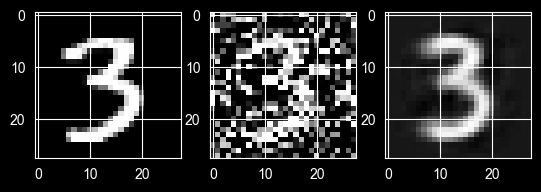

In [91]:
n = 10000

plt.subplot(1,3,1)
plt.imshow(X[n].reshape(28,28), cmap='Greys_r',label = "Original image")


plt.subplot(1,3,2)
plt.imshow(noisy_X[n].reshape(28,28), cmap='Greys_r',label = "Noisy image")

plt.subplot(1,3,3)
denoise = autoencoder.predict([noisy_X[n]])
plt.imshow(denoise.reshape(28,28), cmap='Greys_r',label = "Denoised image")


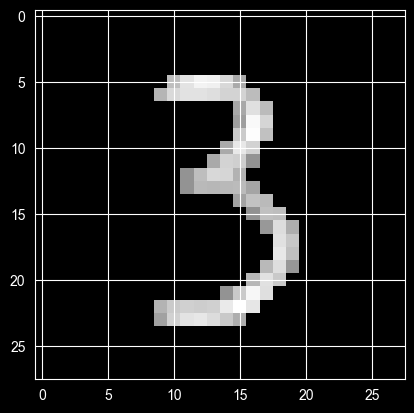

In [93]:
#Post-Processing
denoise[denoise<.6]=0
plt.imshow(denoise.reshape((28,28)), cmap="gray")

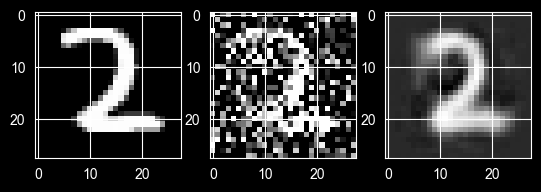

In [95]:
n = 19999

plt.subplot(1,3,1)
plt.imshow(X[n].reshape(28,28), cmap='Greys_r',label = "Original image")


plt.subplot(1,3,2)
plt.imshow(noisy_X[n].reshape(28,28), cmap='Greys_r',label = "Noisy image")

plt.subplot(1,3,3)
denoise = autoencoder.predict([noisy_X[n]])
plt.imshow(denoise.reshape(28,28), cmap='Greys_r',label = "Denoised image")
